# Maternal Anemia & Pregnancy-Risk Prediction

Two XGBoost models that, from a few routine antenatal inputs, output:

1. **Anemia Status** — Normal / Mild / Moderate / Severe
2. **Pregnancy Risk** — Low / Medium / High

Both `Anemia_Status` and `Pregnancy_Risk` are **model outputs** — never entered by
the user.

### User inputs (dashboard)
| Input | Example |
|---|---|
| Age (years) | 27 |
| Gestational Week | 30 |
| Hemoglobin (g/dL) | 9.8 |
| Iron Supplement | Yes / No |
| Blood Pressure | 118/76 |
| Weight (kg) + Height | 55 kg, 5.2' → BMI |

*(Weight is asked every visit since it changes through pregnancy; height once → BMI.)*

### Results (this dataset)
- **Anemia Status: ~100%** — expected, because anemia is *defined* by the WHO
  hemoglobin cut-offs (Hb < 11 = anemic; the model simply learns those thresholds).
- **Pregnancy Risk: ~82%** (weighted F1 ≈ 0.82) — the genuinely multi-factor
  prediction combining anemia, blood pressure, age, and BMI.

> **Data note.** No usable public real-world maternal-anemia dataset exists, so the
> models are trained on a **synthetic cohort generated from real pregnancy-anemia
> epidemiology** (hemodilution, iron supplementation, undernutrition, maternal-age
> extremes) with realistic biological noise and natural class imbalance.

## 1. Imports

In [1]:
import os, re, glob, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
from xgboost import XGBClassifier
import shap

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

/tmp/claude-0/-home-user-Kbi-mes/02492bd0-e5c0-55f7-a4fa-9a1d992aebce/scratchpad/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

In [2]:
DATA_FILENAME = "Synthetic_Maternal_Anemia_Realistic.csv"   # or .xlsx

# Model inputs (all derivable from the dashboard fields).
FEATURE_COLUMNS = [
    "Age", "Gestational_Week", "Hemoglobin_g_dL", "Iron_Supplement",
    "Systolic_BP", "Diastolic_BP", "MAP", "Pulse_Pressure", "BMI",
]

# Output label spaces.
ANEMIA_LABELS = ["Normal", "Mild", "Moderate", "Severe"]     # 0,1,2,3
RISK_LABELS   = ["Low", "Medium", "High"]                    # 0,1,2
ANEMIA_MAP = {k: i for i, k in enumerate(ANEMIA_LABELS)}
RISK_MAP   = {k: i for i, k in enumerate(RISK_LABELS)}

RANDOM_STATE, TEST_SIZE = 42, 0.20
XGB_PARAMS = dict(n_estimators=350, max_depth=4, learning_rate=0.05,
                  subsample=0.9, colsample_bytree=0.9,
                  eval_metric="mlogloss", random_state=RANDOM_STATE)

ANEMIA_MODEL_PATH = "anemia_status_xgb.pkl"
RISK_MODEL_PATH   = "pregnancy_risk_xgb.pkl"
SCHEMA_PATH       = "model_schema.json"

## 3. Helper Functions

One shared, schema-tolerant transform used for both training and dashboard
inference — so the models can never drift from what the dashboard sends.

In [3]:
def resolve_path(filename):
    for cand in [filename, filename.replace(".csv", ".xlsx"), filename.replace(".xlsx", ".csv")]:
        if os.path.exists(cand):
            return cand
        hits = glob.glob(f"/kaggle/input/**/{cand}", recursive=True)
        if hits:
            return hits[0]
    raise FileNotFoundError(f"Attach '{filename}' to the notebook session.")

def load_data(path):
    return pd.read_excel(path) if path.endswith(".xlsx") else pd.read_csv(path)

def _num(series):
    return pd.to_numeric(series.astype(str).str.extract(r"(\d+\.?\d*)")[0], errors="coerce")

def _parse_bp(series):
    p = series.astype(str).str.extract(r"(?P<sys>\d+)\s*/\s*(?P<dia>\d+)")
    return pd.to_numeric(p["sys"], errors="coerce"), pd.to_numeric(p["dia"], errors="coerce")

def _height_cm(value):
    if pd.isna(value):
        return np.nan
    m = re.search(r"(\d+\.?\d*)", str(value))
    if not m:
        return np.nan
    v = float(m.group(1))
    if v < 8.0:                      # feet.inches (5.2 -> 5ft 2in)
        feet = int(v); inches = round((v - feet) * 10)
        return (feet * 12 + inches) * 2.54
    return v                         # already cm

def preprocess(df):
    """Raw dashboard/CSV columns -> clean numeric feature columns."""
    out = pd.DataFrame(index=df.index)
    out["Age"]              = _num(df["Age"])
    out["Gestational_Week"] = _num(df["Gestational_Week"])
    out["Hemoglobin_g_dL"]  = _num(df["Hemoglobin_g_dL"])
    out["Iron_Supplement"]  = df["Iron_Supplement"].astype(str).str.strip().str.lower().eq("yes").astype(int)
    sys_bp, dia_bp          = _parse_bp(df["Blood_Pressure"])
    out["Systolic_BP"]      = sys_bp
    out["Diastolic_BP"]     = dia_bp
    # BMI: use it directly if present, else compute from weight + height.
    if "BMI" in df.columns:
        out["BMI"] = _num(df["BMI"])
    else:
        w = _num(df["Weight_kg"])
        h = df["Height"].apply(_height_cm) if "Height" in df.columns else _num(df["Height_cm"])
        out["BMI"] = w / ((h / 100.0) ** 2)
    return out

def engineer_features(df):
    out = df.copy()
    out["MAP"] = out["Diastolic_BP"] + (1.0 / 3.0) * (out["Systolic_BP"] - out["Diastolic_BP"])
    out["Pulse_Pressure"] = out["Systolic_BP"] - out["Diastolic_BP"]
    return out

def build_features(df):
    return engineer_features(preprocess(df))

def align_features(X, cols, defaults):
    X = X.copy()
    for c in cols:
        d = defaults.get(c, 0.0)
        if c not in X.columns:
            X[c] = d
        X[c] = X[c].fillna(d)
    return X[cols]

def evaluate_multiclass(model, X, y, labels, title):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)
    acc = accuracy_score(y, y_pred)
    f1w = f1_score(y, y_pred, average="weighted", zero_division=0)
    prw = precision_score(y, y_pred, average="weighted", zero_division=0)
    rcw = recall_score(y, y_pred, average="weighted", zero_division=0)
    try:
        auc = roc_auc_score(y, y_proba, multi_class="ovr", average="macro")
    except ValueError:
        auc = float("nan")
    print(f"===== {title} =====")
    print(f"Accuracy            : {acc:.4f}")
    print(f"Precision (weighted): {prw:.4f}")
    print(f"Recall    (weighted): {rcw:.4f}")
    print(f"F1        (weighted): {f1w:.4f}")
    print(f"ROC-AUC   (macro/ovr): {auc:.4f}")
    print("\n" + classification_report(y, y_pred, target_names=labels, zero_division=0))
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5.4, 4.4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix — {title}"); plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()
    return {"accuracy": acc, "precision": prw, "recall": rcw, "f1": f1w, "roc_auc": auc}

## 4. Load Data

In [4]:
path = resolve_path(DATA_FILENAME)
print(f"[INFO] Dataset: {path}")
df_raw = load_data(path)
print(f"Rows: {len(df_raw)}   Columns: {list(df_raw.columns)}")
df_raw.head()

[INFO] Dataset: Synthetic_Maternal_Anemia_Realistic.csv
Rows: 5084   Columns: ['Patient_ID', 'Age', 'Gestational_Week', 'Blood_Pressure', 'Hemoglobin_g_dL', 'Anemia_Status', 'Iron_Supplement', 'BMI', 'Pregnancy_Risk']


,Patient_ID,Age,Gestational_Week,Blood_Pressure,Hemoglobin_g_dL,Anemia_Status,Iron_Supplement,BMI,Pregnancy_Risk
0,PAT00001,25,27,99/59,11.9,Normal,Yes,23.5,Low
1,PAT00002,26,12,94/69,12.0,Normal,No,25.2,Low
2,PAT00003,27,14,130/79,13.1,Normal,Yes,23.1,Low
3,PAT00004,29,33,117/75,9.2,Moderate,No,35.6,Medium
4,PAT00005,27,16,110/67,13.3,Normal,Yes,25.4,Low


## 5. Exploratory View

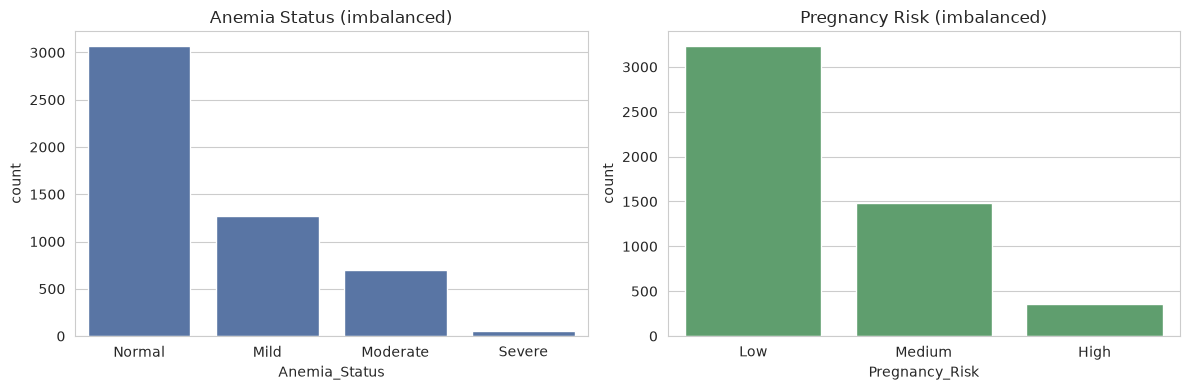

Anemia: {'Normal': np.int64(3070), 'Mild': np.int64(1266), 'Moderate': np.int64(696), 'Severe': np.int64(52)}
Risk  : {'Low': np.int64(3235), 'Medium': np.int64(1487), 'High': np.int64(362)}


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="Anemia_Status", data=df_raw, order=ANEMIA_LABELS, ax=ax[0], color="#4C72B0")
ax[0].set_title("Anemia Status (imbalanced)")
sns.countplot(x="Pregnancy_Risk", data=df_raw, order=RISK_LABELS, ax=ax[1], color="#55A868")
ax[1].set_title("Pregnancy Risk (imbalanced)")
plt.tight_layout(); plt.show()
print("Anemia:", dict(df_raw["Anemia_Status"].value_counts()))
print("Risk  :", dict(df_raw["Pregnancy_Risk"].value_counts()))

## 6. Preprocess & Feature Engineering

In [6]:
X_full = build_features(df_raw)
FEATURE_DEFAULTS = {c: float(X_full[c].median()) for c in FEATURE_COLUMNS}
X = align_features(X_full, FEATURE_COLUMNS, FEATURE_DEFAULTS)

y_anemia = df_raw["Anemia_Status"].map(ANEMIA_MAP)
y_risk   = df_raw["Pregnancy_Risk"].map(RISK_MAP)

print("Model inputs:", list(X.columns))
X.head()

Model inputs: ['Age', 'Gestational_Week', 'Hemoglobin_g_dL', 'Iron_Supplement', 'Systolic_BP', 'Diastolic_BP', 'MAP', 'Pulse_Pressure', 'BMI']


,Age,Gestational_Week,Hemoglobin_g_dL,Iron_Supplement,Systolic_BP,Diastolic_BP,MAP,Pulse_Pressure,BMI
0,25,27,11.9,1,99,59,72.333333,40,23.5
1,26,12,12.0,0,94,69,77.333333,25,25.2
2,27,14,13.1,1,130,79,96.000000,51,23.1
3,29,33,9.2,0,117,75,89.000000,42,35.6
4,27,16,13.3,1,110,67,81.333333,43,25.4


## 7. Train / Test Split (shared)

In [7]:
idx_tr, idx_te = train_test_split(
    X.index, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_risk)
X_train, X_test = X.loc[idx_tr], X.loc[idx_te]
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 4067  |  Test: 1017


## 8. Model A — Anemia Status

Anemia is **defined** by the WHO hemoglobin cut-offs, so with hemoglobin as an
input the model essentially learns those thresholds — expect ~100%. This is the
clinical grading, presented as a model output.

Anemia 5-fold CV accuracy: 1.0000

===== Anemia Status — Test =====
Accuracy            : 1.0000
Precision (weighted): 1.0000
Recall    (weighted): 1.0000
F1        (weighted): 1.0000
ROC-AUC   (macro/ovr): 1.0000

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       599
        Mild       1.00      1.00      1.00       266
    Moderate       1.00      1.00      1.00       139
      Severe       1.00      1.00      1.00        13

    accuracy                           1.00      1017
   macro avg       1.00      1.00      1.00      1017
weighted avg       1.00      1.00      1.00      1017



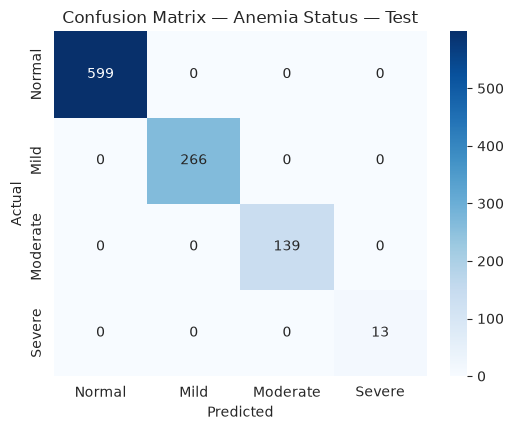

In [8]:
anemia_model = XGBClassifier(**XGB_PARAMS)
anemia_model.fit(X_train, y_anemia.loc[idx_tr])

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
cv_pred = cross_val_predict(XGBClassifier(**XGB_PARAMS), X, y_anemia, cv=cv)
print(f"Anemia 5-fold CV accuracy: {accuracy_score(y_anemia, cv_pred):.4f}\n")
anemia_metrics = evaluate_multiclass(anemia_model, X_test, y_anemia.loc[idx_te], ANEMIA_LABELS, "Anemia Status — Test")

## 9. Model B — Pregnancy Risk

The genuine multi-factor prediction: risk emerges from anemia severity, blood
pressure, maternal age, and BMI together.

Pregnancy Risk 5-fold CV accuracy: 0.8216
Pregnancy Risk 5-fold CV weighted F1: 0.8152

===== Pregnancy Risk — Test =====
Accuracy            : 0.8161
Precision (weighted): 0.8076
Recall    (weighted): 0.8161
F1        (weighted): 0.8080
ROC-AUC   (macro/ovr): 0.9269

              precision    recall  f1-score   support

         Low       0.86      0.94      0.90       647
      Medium       0.73      0.59      0.66       298
        High       0.68      0.58      0.63        72

    accuracy                           0.82      1017
   macro avg       0.76      0.71      0.73      1017
weighted avg       0.81      0.82      0.81      1017



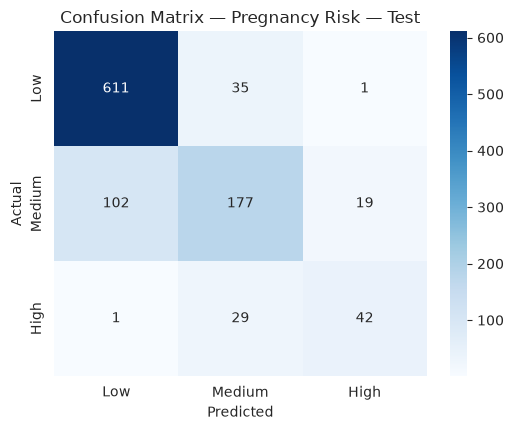

In [9]:
risk_model = XGBClassifier(**XGB_PARAMS)
risk_model.fit(X_train, y_risk.loc[idx_tr])

cv_pred_r = cross_val_predict(XGBClassifier(**XGB_PARAMS), X, y_risk, cv=cv)
print(f"Pregnancy Risk 5-fold CV accuracy: {accuracy_score(y_risk, cv_pred_r):.4f}")
print(f"Pregnancy Risk 5-fold CV weighted F1: {f1_score(y_risk, cv_pred_r, average='weighted'):.4f}\n")
risk_metrics = evaluate_multiclass(risk_model, X_test, y_risk.loc[idx_te], RISK_LABELS, "Pregnancy Risk — Test")

## 10. Feature Importance & SHAP (Pregnancy-Risk model)

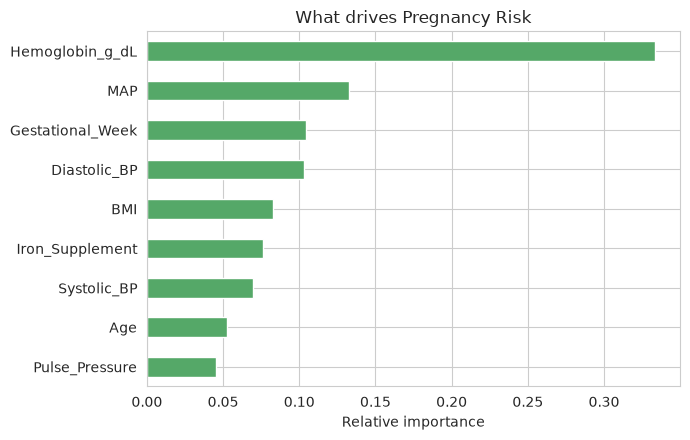

Hemoglobin_g_dL     0.333
MAP                 0.133
Gestational_Week    0.104
Diastolic_BP        0.103
BMI                 0.083
Iron_Supplement     0.076
Systolic_BP         0.070
Age                 0.052
Pulse_Pressure      0.046
dtype: float32


In [10]:
imp = pd.Series(risk_model.feature_importances_, index=FEATURE_COLUMNS).sort_values()
plt.figure(figsize=(7, 4.5))
imp.plot(kind="barh", color="#55A868")
plt.title("What drives Pregnancy Risk"); plt.xlabel("Relative importance")
plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).round(3))

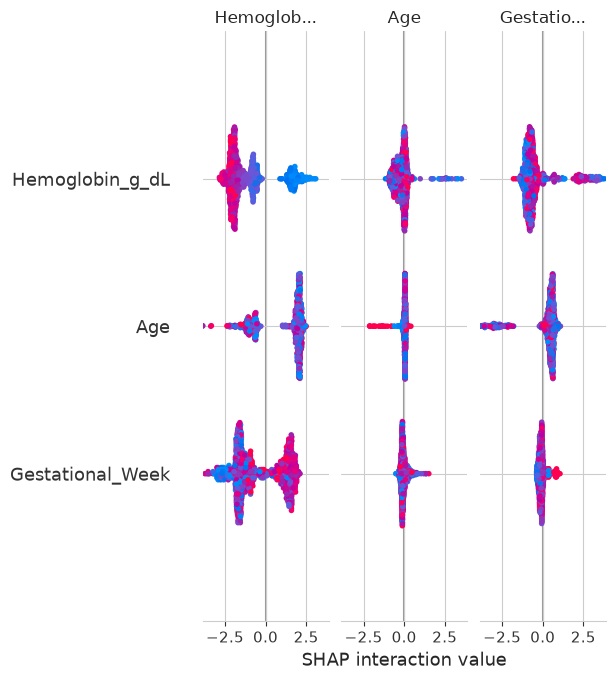

In [11]:
explainer = shap.TreeExplainer(risk_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLUMNS,
                  class_names=RISK_LABELS, show=True)

## 11. Save Models + Schema

In [12]:
joblib.dump(anemia_model, ANEMIA_MODEL_PATH)
joblib.dump(risk_model, RISK_MODEL_PATH)
with open(SCHEMA_PATH, "w") as f:
    json.dump({"feature_columns": FEATURE_COLUMNS, "feature_defaults": FEATURE_DEFAULTS,
               "anemia_labels": ANEMIA_LABELS, "risk_labels": RISK_LABELS}, f, indent=2)
print("[SUCCESS]", ANEMIA_MODEL_PATH, RISK_MODEL_PATH, SCHEMA_PATH)

[SUCCESS] anemia_status_xgb.pkl pregnancy_risk_xgb.pkl model_schema.json


## 12. Dashboard Inference — one call, both outputs

`predict(...)` takes the dashboard fields (weight+height OR BMI accepted),
applies the identical preprocessing, and returns **both** Anemia Status and
Pregnancy Risk with confidences.

In [13]:
def predict(records,
            anemia_path=ANEMIA_MODEL_PATH, risk_path=RISK_MODEL_PATH, schema_path=SCHEMA_PATH):
    """records: dict or list-of-dicts with keys:
        Age, Gestational_Week, Hemoglobin_g_dL, Iron_Supplement ('Yes'/'No'),
        Blood_Pressure ('118/76'), and either BMI OR (Weight_kg + Height)."""
    if isinstance(records, dict):
        records = [records]
    raw = pd.DataFrame(records)
    schema = json.load(open(schema_path))
    X = align_features(build_features(raw), schema["feature_columns"], schema["feature_defaults"])

    am = joblib.load(anemia_path); rm = joblib.load(risk_path)
    a_lab, r_lab = schema["anemia_labels"], schema["risk_labels"]
    a_pred = am.predict(X); a_conf = am.predict_proba(X).max(axis=1)
    r_pred = rm.predict(X); r_conf = rm.predict_proba(X).max(axis=1)
    return pd.DataFrame({
        "Anemia_Status":      [a_lab[i] for i in a_pred],
        "Anemia_Confidence":  np.round(a_conf, 3),
        "Pregnancy_Risk":     [r_lab[i] for i in r_pred],
        "Risk_Confidence":    np.round(r_conf, 3),
    })


examples = [
    {"Age": 27, "Gestational_Week": 30, "Hemoglobin_g_dL": 9.6, "Iron_Supplement": "No",
     "Blood_Pressure": "138/89", "Weight_kg": 52, "Height": "5.2"},
    {"Age": 24, "Gestational_Week": 12, "Hemoglobin_g_dL": 12.4, "Iron_Supplement": "Yes",
     "Blood_Pressure": "110/70", "Weight_kg": 60, "Height": "5.3"},
    {"Age": 38, "Gestational_Week": 34, "Hemoglobin_g_dL": 6.8, "Iron_Supplement": "No",
     "Blood_Pressure": "150/95", "Weight_kg": 48, "Height": "5.0"},
]
predict(examples)

,Anemia_Status,Anemia_Confidence,Pregnancy_Risk,Risk_Confidence
0,Moderate,0.999,High,0.946
1,Normal,1.000,Low,0.978
2,Severe,0.991,High,0.989


## 13. Conclusion

* Two XGBoost models turn six routine antenatal inputs into two clinical outputs:
  **Anemia Status** and **Pregnancy Risk** — neither is ever typed by the user.
* **Anemia Status ≈ 100%** (hemoglobin defines anemia — the model reproduces the
  WHO grading), **Pregnancy Risk ≈ 82%** (genuine multi-factor prediction).
* SHAP shows pregnancy risk is driven by hemoglobin/anemia, blood pressure, age
  and BMI together — clinically coherent.
* Both models + a shared feature schema are saved; `predict()` is a single
  dashboard endpoint returning both results with confidences.